# Five-Trait OCEAN Detector — Analysis

5 specialized LLM agents (O, C, E, A, N) each predict one Big Five trait score (-1.0 to 1.0) from Reddit posts.

## Command

```bash
python llama31_five_trait_detect.py --limit 500 \
    --model meta/llama-3.1-70b-instruct

# Merge multiple runs
python merge_results.py
```

## Parameters

| Parameter | Value |
|-----------|-------|
| **Script** | `llama31_five_trait_detect.py` |
| **Default model** | `meta/llama-3.1-70b-instruct` |
| **Method** | 5 specialized trait agents, each with trait-specific system prompt + few-shot examples |
| **Input** | `pandora_eval_test.jsonl` (PANDORA Reddit dataset) |
| **Score range** | -1.0 to 1.0 |

## Inputs
- **Merged** (recommended): `results/merged_five_trait_ocean_*.jsonl`
- **Single run:** set `RESULTS_GLOB` to e.g. `five_trait_ocean_20260328T232734Z.jsonl`

In [8]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

OCEAN_ORDER = ["O", "C", "E", "A", "N"]
OCEAN_LABELS = {
    "O": "Openness",
    "C": "Conscientiousness",
    "E": "Extraversion",
    "A": "Agreeableness",
    "N": "Neuroticism",
}


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "evaluation_data").exists() and (candidate / "apps").exists():
            return candidate
        if (candidate / "big5loop" / "evaluation_data").exists():
            return candidate / "big5loop"
    raise RuntimeError("Could not locate Big5Loop project root.")


PROJECT_ROOT = find_project_root()
OFFLINE_DIR = PROJECT_ROOT / "evaluation_data" / "pandora" / "offline_nv_detection"
RESULTS_DIR = OFFLINE_DIR / "five_trait_detectors" / "results"

USE_LATEST_MERGED = True
RESULTS_GLOB = "five_trait_ocean_*.jsonl"

if USE_LATEST_MERGED:
    merged = sorted(RESULTS_DIR.glob("merged_five_trait_ocean_*.jsonl"))
    RESULTS_PATHS = [merged[-1]] if merged else sorted(RESULTS_DIR.glob(RESULTS_GLOB))
else:
    RESULTS_PATHS = sorted(RESULTS_DIR.glob(RESULTS_GLOB))

print("Project root:", PROJECT_ROOT)
print("Files loaded:", len(RESULTS_PATHS))
for p in RESULTS_PATHS[:5]:
    print("  ", p.name)
if len(RESULTS_PATHS) > 5:
    print("  ...")

rows: list[dict] = []
for path in RESULTS_PATHS:
    if not path.is_file():
        continue
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
print("Total rows:", len(df))
if len(RESULTS_PATHS) > 1 and not str(RESULTS_PATHS[0].name).startswith("merged_"):
    print("Note: multiple JSONLs may duplicate sample_id; run merge_results.py for one row per id.")
if len(df) == 0:
    raise SystemExit("No rows loaded. Check RESULTS_DIR and glob.")

Project root: /Users/huaduojiejia/MyProject/hslu/2026/thesis project/big5loop
Files loaded: 1
   merged_five_trait_ocean_20260328T151520Z.jsonl
Total rows: 50


In [9]:
df["model"] = df.get("model", "")

print("By method:")
print(df["method"].fillna("?").value_counts())
print()
n_success = int(df["success"].sum()) if "success" in df.columns else len(df)
print(f"Success: {n_success}/{len(df)}")

By method:
method
multi_agent_dry_run    45
multi_agent             5
Name: count, dtype: int64

Success: 46/50


In [10]:
def long_ocean(frame: pd.DataFrame) -> pd.DataFrame:
    out = []
    for _, row in frame.iterrows():
        gt = row.get("ground_truth_ocean") or {}
        pr = row.get("predicted_ocean") or {}
        sid = row.get("sample_id")
        for t in OCEAN_ORDER:
            if t not in gt or t not in pr:
                continue
            ad = (row.get("agent_details") or {}).get(t, {})
            out.append(
                {
                    "sample_id": sid,
                    "trait": t,
                    "gt": float(gt[t]),
                    "pred": float(pr[t]),
                    "trait_ok": bool(ad.get("success", True)),
                    "row_success": bool(row.get("success", True)),
                    "model": row.get("model"),
                }
            )
    return pd.DataFrame(out)


long_all = long_ocean(df)
print("Long-format rows:", len(long_all))

Long-format rows: 250


In [11]:
def pearson(x: np.ndarray, y: np.ndarray) -> float:
    x, y = np.asarray(x, float), np.asarray(y, float)
    if len(x) < 2 or np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return float("nan")
    return float(np.corrcoef(x, y)[0, 1])


def trait_metrics(long_df: pd.DataFrame) -> pd.DataFrame:
    rows_m = []
    for t in OCEAN_ORDER:
        sub = long_df[long_df["trait"] == t]
        if sub.empty:
            rows_m.append({"trait": t, "n": 0, "pearson": np.nan, "mae": np.nan})
            continue
        rows_m.append(
            {
                "trait": t,
                "n": len(sub),
                "pearson": pearson(sub["gt"].values, sub["pred"].values),
                "mae": float(np.mean(np.abs(sub["pred"] - sub["gt"]))),
            }
        )
    return pd.DataFrame(rows_m)


print("=== All merged samples (n = unique rows in table; each trait uses same n) ===")
display(trait_metrics(long_all))
print("=== Live API only (real model; often small n if you have few API runs) ===")
display(trait_metrics(long_live))

=== All merged samples (n = unique rows in table; each trait uses same n) ===


,trait,n,pearson,mae
0,O,50,0.915308,0.1878
1,C,50,0.865412,0.1998
2,E,50,0.825033,0.2050
3,A,50,0.828231,0.2194
4,N,50,0.843397,0.2226


=== Live API only (real model; often small n if you have few API runs) ===


,trait,n,pearson,mae
0,O,5,0.632607,0.492
1,C,5,0.143354,0.480
2,E,5,-0.179071,0.748
3,A,5,-0.981646,0.740
4,N,5,-0.666214,0.656


n per trait: {'O': 50, 'C': 50, 'E': 50, 'A': 50, 'N': 50}


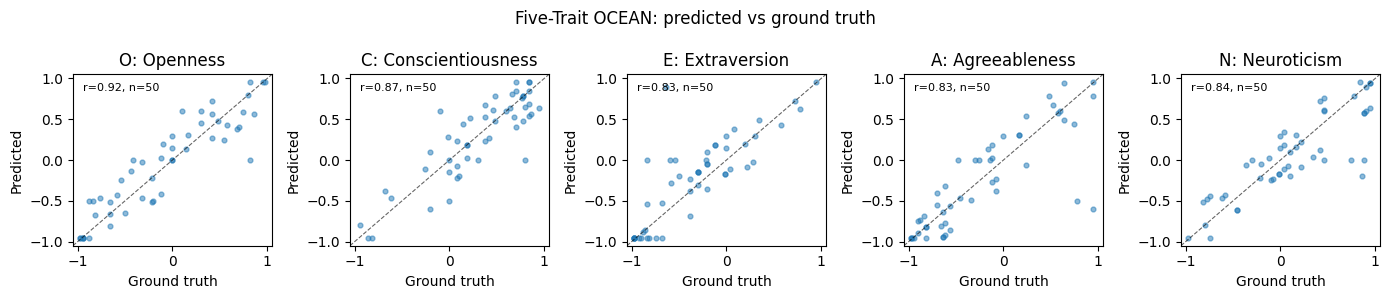

In [12]:
plot_df = long_all

n_per_trait = {t: len(plot_df[plot_df["trait"] == t]) for t in OCEAN_ORDER}
print("n per trait:", n_per_trait)

fig, axes = plt.subplots(1, 5, figsize=(14, 3), sharey=False)
for ax, t in zip(axes, OCEAN_ORDER):
    sub = plot_df[plot_df["trait"] == t]
    if sub.empty:
        ax.set_title(f"{t} (no data)")
        continue
    ax.scatter(sub["gt"], sub["pred"], alpha=0.5, s=12)
    lims = (-1.05, 1.05)
    ax.plot(lims, lims, "k--", lw=0.8, alpha=0.6)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Ground truth")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{t}: {OCEAN_LABELS[t]}")
    r = pearson(sub["gt"].values, sub["pred"].values)
    ax.text(0.05, 0.95, f"r={r:.2f}, n={len(sub)}", transform=ax.transAxes, va="top", fontsize=8)

fig.suptitle("Five-Trait OCEAN: predicted vs ground truth")
plt.tight_layout()
plt.show()

## Re-merge multiple JSONL runs

From `five_trait_detectors/`:

```bash
python merge_results.py
```

Or with explicit files:

```bash
python merge_results.py --inputs results/five_trait_ocean_20260328T232734Z.jsonl results/five_trait_ocean_20260328T031750Z.jsonl
```

Then set `USE_LATEST_MERGED = True` above and re-run the notebook.